# Distribution
Following the "Thinkt stats" book, on of the series of "Think ..." from Allen Downey, i'll try to replicate the practical and data oriented approach of statistics instead of the classical mathematical one. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from empiricaldist import Pmf

## The Binomial Distribution
As in any binomial distribution cases we are trying to model an event that has just two possible cases: success or not success. I've used the term success just becasue i believe that it fit the purpose of that applied oriented approach described before, the binomial distribution, actually, mmodels any event with two possible realization (turning right or left would have done the same purpose).

In it's notebook, Downey, used as example the sport of skeet shooting, which is something i'm not that familiar with. I'll, instead, use as an example what is really bothering me at the time of which i'm writing this notebooks: trains and them being late. 

In this first example, we will assume that a train has just two possible outcomes, it being on time or it being late. We are not taking into account all the possible causes for them to be late. 

So, as a model, let suppose that every train has the same probability $\mathb{p}$  of being in time. 

To simulate the model, i'll use the following function, which takes the number of trains, $\math{n}$ and the probability of being in time, $\math{p}$, and returns a sequene of 1s and 0s to indiate being on time or being late.



In [3]:
def time(n,p): 
    choices = [1, 0]
    probs = [p, 1-p]
    return np.random.choice(choices, n, p = probs)

Here is an example that simulates 25 trains, let say the number of trains that come through "Genova Principe" in half an hour (?), and let's assume that each trains has the probability of being in time of about 90\%

In [4]:
np.random.seed(1) #Set a seed for reproducibility (Pseudonumber generator)


In [5]:
time(25, 0.9)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1])

We can use the function to create a longer sequence and compute the probability mass function, from the empiricaldist library, and see if the proportion of 1s and 0s are correct, at least qpproximately.

In [8]:
from empiricaldist import Pmf

seq = time(1000, 0.9)
pmf = Pmf.from_seq(seq)
pmf

,probs
0,0.101
1,0.899


Good! If we increase the number of trains (the n) then the probability of 0s and 1s will eventually converge to our desired ones. 

Now we can use the "time" function to simulate a day at the station and return the number of on time trains. 

In [10]:
def simulate_day_at_the_station(n, p):
    seq = time(n, p)
    return seq.sum()

I've been very optimistic before. I'm from Italy and it's general knowledge that we have poor train effectivness. 
If it comes down just to a metter of my personal experience, which is exactly how i will struvture this example from now on, i'd say that 2 train out of 3 will be late. 

Keeping in mind that in Italy we have approximately arond 2.200 station, of course i asked claude this number, so that we are adding uncertanty over uncertanty, we can simulate a day at the station in Italy by calling the unction 2200 times. 

In [ ]:
n = 100 
p = 0.33
result = [simulate_day_at_the_station(n, p) for i in range(2200) ]


np.float64(33.00636363636364)

Just a simple specification: here the "result" is just the result from an iteration over a loop "for", so it is the list of the various result. In order to see the mean we need to call the Numpy object. 

In [16]:
np.mean(result), n *p

(np.float64(33.00636363636364), 33.0)

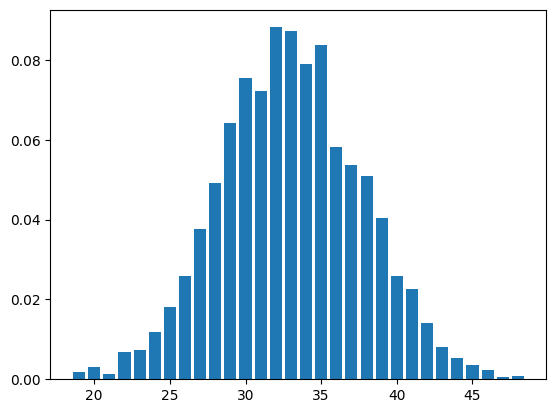

In [17]:
from empiricaldist import Pmf

pmf_sim = Pmf.from_seq(result, name = "Simulation results")
pmf_sim.bar()

From the graph we can see the shape of the distribution, and it closely resembles a normal (bell-shaped) curve. It's worth being careful about *why* this happens, because there are two different "large numbers" at play, and only one of them is actually responsible for the shape.

- Each simulated day, `simulate_day_at_the_station(n, p)`, is the **sum of `n = 100` independent on-time / late outcomes**. A sum of many independent two-outcome (Bernoulli) trials is itself approximately normal, as long as `n` is reasonably large and `p` is not too close to 0 or 1. This is the Central Limit Theorem (and for the binomial specifically, the de Moivre–Laplace theorem). *This* is what gives the distribution its bell shape.
- The `2200` repetitions, on the other hand, are just how many days (stations) we **sampled** from that distribution. Increasing this number does not change the underlying shape; it only makes the empirical PMF a smoother, less noisy estimate of the true distribution.

So the normal-like shape comes from `n` being large, **not** from running the simulation 2200 times.

To see this, let's change the parameter that actually matters. Instead of lowering the number of stations, let's lower the probability `p` to `0.05` (keeping `n = 100`). Now the expected number of on-time trains is only `n·p = 5`, which is small. We'll see that the bell shape breaks down and the distribution becomes visibly skewed — confirming that it was `n·p` being large enough, not the number of repetitions, that made the previous plot look normal.

In [29]:
n = 100 
p = 0.05
result_2 = [simulate_day_at_the_station(n, p) for i in range(2200)]

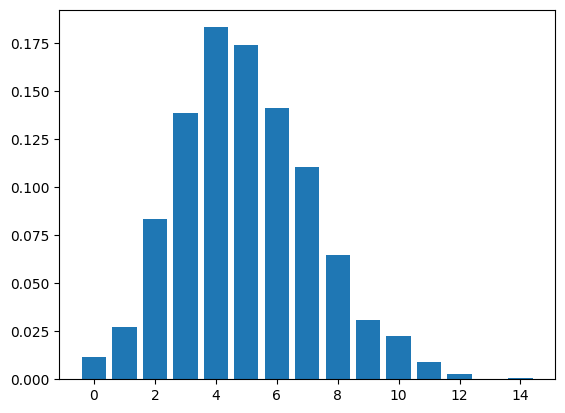

In [28]:
pmf_result_2 = Pmf.from_seq(result_2)

pmf_result_2.bar()

Following the same approach of Downey, we could have predicted this distribution without having simulated it. Mathematically, the distribution follows a binomial distribution, which has a PMF that is easy to compute, if not the easiest. 

In [ ]:
from scipy.special import comb

def binomial_pmf(k,n,p):
    return comb(n, k) * (p**k) * ((1-p)** (n-k))

The comb function from SciPy computes the number of combination of "n" things taken "k" at a time. This is basically the binomial coefficient: 
